<h1 style="margin:0;color:#3776AB;">
🐍 Pythonize com Tomane | #022
</h1>

### Organizar as datas dos produtos da despensa com Python

#### 💡 Sabias que podes acompanhar as datas dos teus produtos e ver o que precisa de atenção nos próximos dias?

#### Neste code, vou criar uma lista de exemplo, calcular quantos dias faltam para cada data indicada no rótulo e mostrar tudo num gráfico. Depois, é só trocares os produtos pelos que tens em casa.

#### 1. Importar as bibliotecas

Se não tiveres o `matplotlib`, instala no Jupyter com `%pip install matplotlib`. A biblioteca das datas já vem com Python.

In [1]:
from datetime import date, timedelta
from collections import Counter
import matplotlib.pyplot as plt


#### 2. Preparar a lista de produtos

As datas abaixo são relativas ao dia em que executas o notebook. Assim, podes repetir o exemplo a qualquer momento.

In [2]:
hoje = date.today()

produtos = [
    {"nome": "Iogurte", "local": "Frigorífico", "data_rotulo": hoje - timedelta(days=1)},
    {"nome": "Pão", "local": "Despensa", "data_rotulo": hoje + timedelta(days=1)},
    {"nome": "Leite", "local": "Frigorífico", "data_rotulo": hoje + timedelta(days=2)},
    {"nome": "Queijo", "local": "Frigorífico", "data_rotulo": hoje + timedelta(days=3)},
    {"nome": "Ovos", "local": "Frigorífico", "data_rotulo": hoje + timedelta(days=6)},
    {"nome": "Arroz", "local": "Despensa", "data_rotulo": hoje + timedelta(days=19)},
    {"nome": "Farinha", "local": "Despensa", "data_rotulo": hoje + timedelta(days=34)},
]

print(f"Data de referência: {hoje.strftime('%d/%m/%Y')}")
print(f"Produtos registados: {len(produtos)}")


Data de referência: 23/09/2026
Produtos registados: 7


#### 3. Calcular os dias que faltam

Vou separar a lista em três grupos: data já passou, até 7 dias e mais tarde. Isto serve para organizar a despensa; confirma sempre o rótulo e as condições de conservação do produto.

In [3]:
for produto in produtos:
    dias = (produto["data_rotulo"] - hoje).days
    produto["dias"] = dias

    if dias < 0:
        produto["situacao"] = "Data já passou"
    elif dias <= 7:
        produto["situacao"] = "Até 7 dias"
    else:
        produto["situacao"] = "Mais tarde"

ordenados = sorted(produtos, key=lambda produto: produto["data_rotulo"])
contagem = Counter(produto["situacao"] for produto in ordenados)

for produto in ordenados:
    print(f"{produto['nome']:<10} | {produto['data_rotulo']:%d/%m/%Y} | "
          f"{produto['dias']:+3d} dia(s) | {produto['situacao']}")


Iogurte    | 22/09/2026 |  -1 dia(s) | Data já passou
Pão        | 24/09/2026 |  +1 dia(s) | Até 7 dias
Leite      | 25/09/2026 |  +2 dia(s) | Até 7 dias
Queijo     | 26/09/2026 |  +3 dia(s) | Até 7 dias
Ovos       | 29/09/2026 |  +6 dia(s) | Até 7 dias
Arroz      | 12/10/2026 | +19 dia(s) | Mais tarde
Farinha    | 27/10/2026 | +34 dia(s) | Mais tarde


#### 4. Ver um resumo rápido

In [4]:
print(f"Data já passou: {contagem['Data já passou']}")
print(f"Até 7 dias: {contagem['Até 7 dias']}")
print(f"Mais tarde: {contagem['Mais tarde']}")


Data já passou: 1
Até 7 dias: 4
Mais tarde: 2


#### 5. Criar os gráficos

No primeiro gráfico, os valores negativos mostram datas que já passaram. No terceiro, aparecem apenas os produtos cuja data fica entre hoje e os próximos 14 dias.

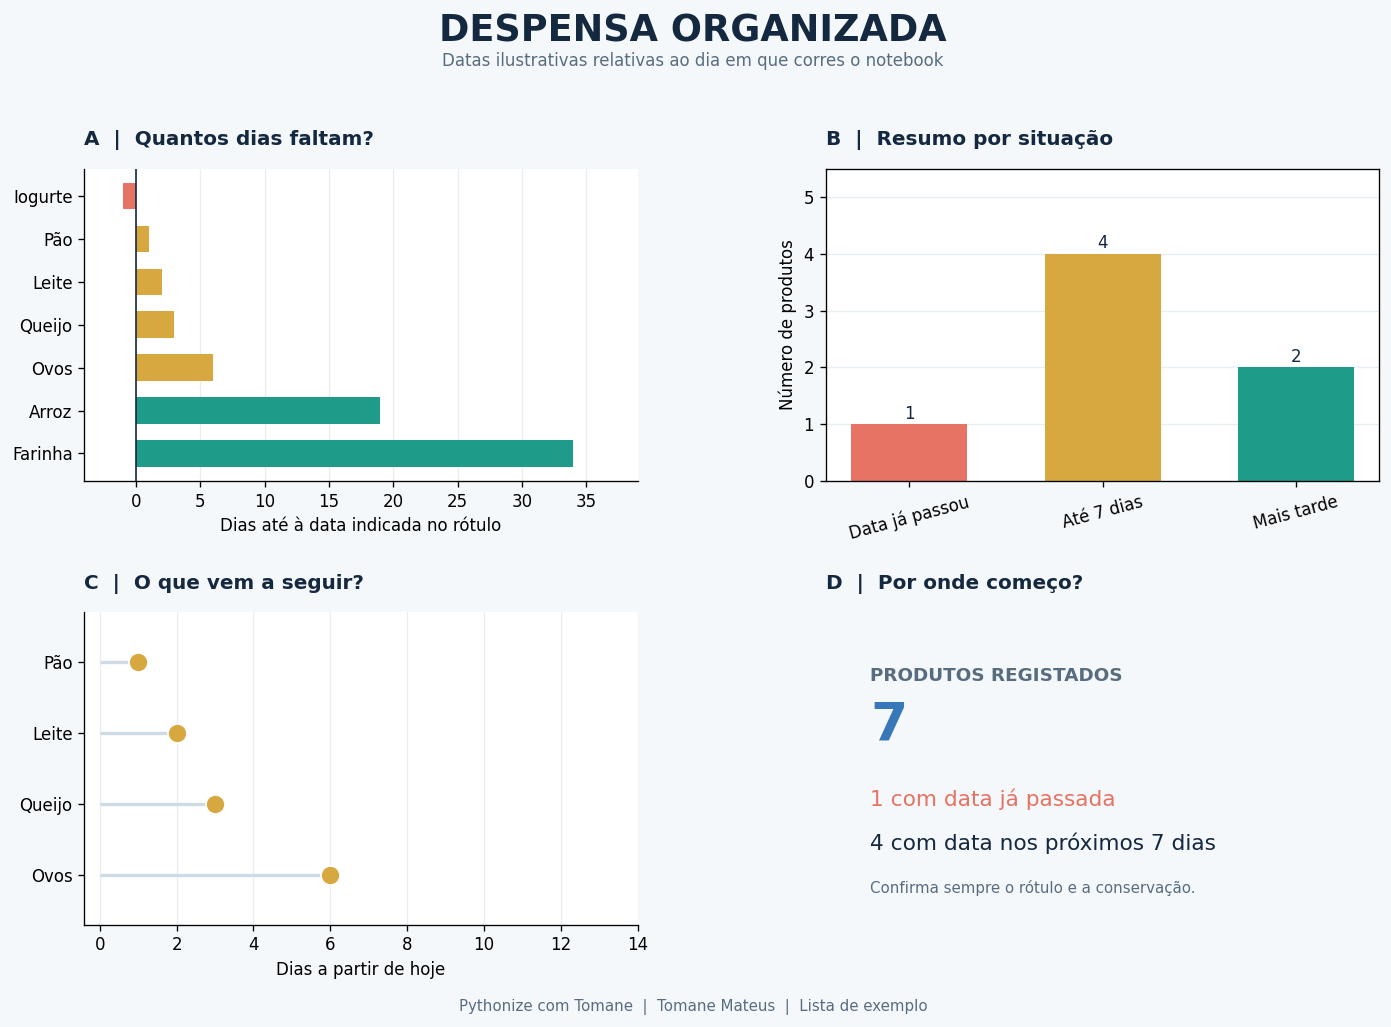

In [5]:
AZUL = "#3878B8"
VERDE = "#1E9C89"
CORAL = "#E67363"
DOURADO = "#D7A83F"
ESCURO = "#14283F"

cores = {
    "Data já passou": CORAL,
    "Até 7 dias": DOURADO,
    "Mais tarde": VERDE,
}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "figure.facecolor": "#F5F8FB",
    "savefig.facecolor": "#F5F8FB",
})

fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(left=0.11, right=0.94, top=0.83,
                    bottom=0.13, wspace=0.34, hspace=0.42)
fig.suptitle("DESPENSA ORGANIZADA", y=0.975,
             fontsize=22, fontweight="bold", color=ESCURO)
fig.text(0.5, 0.925, "Datas ilustrativas relativas ao dia em que corres o notebook",
         ha="center", color="#586C80")

def preparar(ax, titulo):
    ax.set_facecolor("white")
    ax.set_title(titulo, loc="left", pad=14, fontweight="bold", color=ESCURO)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="x", color="#E8EEF4", linewidth=0.8)
    ax.set_axisbelow(True)

# A — Dias até à data do rótulo
ax = axs[0, 0]
preparar(ax, "A  |  Quantos dias faltam?")
nomes = [produto["nome"] for produto in ordenados][::-1]
dias_valores = [produto["dias"] for produto in ordenados][::-1]
cores_barras = [cores[produto["situacao"]] for produto in ordenados][::-1]
ax.barh(nomes, dias_valores, color=cores_barras, height=0.62)
ax.axvline(0, color=ESCURO, linewidth=1)
ax.set_xlabel("Dias até à data indicada no rótulo")
ax.set_xlim(min(dias_valores) - 3, max(dias_valores) + 5)

# B — Quantos produtos há em cada grupo
ax = axs[0, 1]
ax.set_facecolor("white")
ax.set_title("B  |  Resumo por situação", loc="left", pad=14,
             fontweight="bold", color=ESCURO)
situacoes = ["Data já passou", "Até 7 dias", "Mais tarde"]
quantidades = [contagem[s] for s in situacoes]
ax.bar(situacoes, quantidades, color=[cores[s] for s in situacoes], width=0.6)
ax.set(ylabel="Número de produtos", ylim=(0, max(quantidades) + 1.5))
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", color="#E8EEF4")
ax.set_axisbelow(True)
for i, quantidade in enumerate(quantidades):
    ax.text(i, quantidade + 0.1, str(quantidade), ha="center", color=ESCURO)

# C — Produtos com data nos próximos 14 dias
ax = axs[1, 0]
preparar(ax, "C  |  O que vem a seguir?")
proximos = [produto for produto in ordenados if 0 <= produto["dias"] <= 14]
for i, produto in enumerate(proximos):
    ax.scatter(produto["dias"], i, s=130, color=cores[produto["situacao"]],
               edgecolor="white", zorder=3)
    ax.hlines(i, 0, produto["dias"], color="#CEDBE5", linewidth=2)
ax.set_yticks(range(len(proximos)), [produto["nome"] for produto in proximos])
ax.set(xlabel="Dias a partir de hoje", xlim=(-0.4, 14), ylim=(-0.7, len(proximos)-0.3))
ax.invert_yaxis()
ax.set_xticks(range(0, 15, 2))

# D — Resumo sem assumir que o produto está próprio ou impróprio para consumo
ax = axs[1, 1]
ax.set_facecolor("white")
ax.set_title("D  |  Por onde começo?", loc="left", pad=14,
             fontweight="bold", color=ESCURO)
ax.axis("off")
ax.text(0.08, 0.78, "PRODUTOS REGISTADOS", transform=ax.transAxes,
        fontsize=11, fontweight="bold", color="#586C80")
ax.text(0.08, 0.59, str(len(produtos)), transform=ax.transAxes,
        fontsize=32, fontweight="bold", color=AZUL)
ax.text(0.08, 0.38, f"{contagem['Data já passou']} com data já passada",
        transform=ax.transAxes, fontsize=13, color=CORAL)
ax.text(0.08, 0.24, f"{contagem['Até 7 dias']} com data nos próximos 7 dias",
        transform=ax.transAxes, fontsize=13, color=ESCURO)
ax.text(0.08, 0.10, "Confirma sempre o rótulo e a conservação.",
        transform=ax.transAxes, fontsize=9, color="#586C80")

fig.text(0.5, 0.05, "Pythonize com Tomane  |  Tomane Mateus  |  Lista de exemplo",
         ha="center", color="#586C80", fontsize=9)
fig.savefig("Pythonize_022_Datas_Despensa.png", dpi=160, bbox_inches="tight")
plt.show()


Agora podes trocar os produtos da lista e escrever as datas que aparecem nas embalagens. O objetivo é ter tudo organizado e saber o que verificar primeiro; este código não avalia se um alimento está próprio para consumo.

<h3 style="margin-bottom:5px;">
Tomane Mateus
</h3>

<p style="margin-top:0;">
</p>

<p>
🔗 <b>LinkedIn:</b>
<a href="https://www.linkedin.com/in/tomane-mateus-tomane-7a5205123" target="_blank">
www.linkedin.com/in/tomane-mateus-tomane-7a5205123
</a>
</p>
<p>
💻 <b>GitHub:</b>
<a href="https://github.com/Tomane-Pd" target="_blank">
github.com/Tomane-Pd
</a>
</p>
<p>
🌐 <b>Portfolio:</b>
<a href="https://tomane-portfolio.com" target="_blank">
tomane-portfolio.com
</a>
</p>

<hr style="border:1px solid #ddd; width:100%;">

<p style="color:#555;">
 <b>Siga para mais dicas práticas de Python, IA, Data Science e Automação.</b>
</p>

<p style="font-size:13px;color:#888;margin-top:15px;">
© 2026 <b>Tomane Mateus</b>. Todos os direitos reservados.
</p>

</div>